## import python libraries and define functions
#####  numpy, h5 file reader, matplotlib - plotting

In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt


# define functions to read the h5 files
            
def get_tree(f):
    """List the full tree of the h5 file"""
    def printname(name):  # needed because .visit needs callable
        print(name, type(f[name]))
    f.visit(printname)
    
def is_leaf(dataset):
    return isinstance(dataset,h5py.Dataset)

def get_leaves(f,saveto,verbose=False):
    def return_leaf(name):
        if is_leaf(f[name]):
            if verbose:
                print(name,f[name][()].shape)
            saveto[name] = f[name][()]
    f.visit(return_leaf)

def runNumToString(num):
    numstr = str(num)
    while len(numstr)<4:
        numstr = '0'+numstr
    return numstr

# function for plotting Jungfrau detector counts : input coordinates (x,y) and f : data to be plotted

def plot_jungfrau(x,y,f,ax=None,shading='nearest',*args,**kwargs):
    if not ax:
        ax=plt.gca()
    for i in range(8):
        pcm = ax.pcolormesh(x[i],y[i],f[i],shading=shading,*args,**kwargs)
    return pcm

## Next define keys (data parameters) to be loaded and define function to load data
#### (1) keys_to_combine: some keys loaded for each shot & stored per shot (2) keys_to_sum: some keys loaded per each run and added (3) keys_to_check : check if some keys exits and same values in all runs and load these keys 

In [2]:
keys_to_combine = ['jungfrau4M/azav_azav',
                   'evr/code_183',
                   'evr/code_137', # try code_137
                   'lightStatus/laser',
                   'lightStatus/xray']

keys_to_sum = ['Sums/jungfrau4M_calib',
              'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav__azav_q',
                'UserDataCfg/jungfrau4M/azav__azav_qbin',
                'UserDataCfg/jungfrau4M/azav__azav_qbins',
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/azav__azav_matrix_q',
                'UserDataCfg/jungfrau4M/azav__azav_matrix_phi',
                'UserDataCfg/jungfrau4M/cmask',
                # 'UserDataCfg/jungfrau4M/Full_thres__Full_thres_thresADU',
                # 'UserDataCfg/jungfrau4M/Full_thres__Full_thres_bound',
                'UserDataCfg/jungfrau4M/common_mode_pars']

def combineRuns(runNumbers,folder,verbose=False):   # function defined to load the keys listed
    data_array = []
    experiment = folder.split('/')[6]
    for i,runNumber in enumerate(runNumbers):
        data = {}
        filename = f'{folder}{experiment}_Run{runNumToString(runNumber)}.h5'
        print(filename)
        with h5py.File(filename,'r') as f:
            get_leaves(f,data,verbose=verbose)
            data_array.append(data)
    data_combined = {}
    for key in keys_to_combine:
        arr = np.squeeze(data_array[0][key])
        for data in data_array[1:]:
            arr = np.concatenate((arr,np.squeeze(data[key])),axis=0)
        data_combined[key] = arr
    run_indicator = np.array([])
    for i,runNumber in enumerate(runNumbers):
        run_indicator = np.concatenate((run_indicator,runNumber*np.ones_like(data_array[i]['lightStatus/xray'])))
    data_combined['run_indicator'] = run_indicator
    for key in keys_to_sum:
        arr = np.zeros_like(data_array[0][key])
        for data in data_array:
            arr += data[key]
        data_combined[key] = arr
    for key in keys_to_check:
        arr = data_array[0][key]
        for i,data in enumerate(data_array):
            if not np.array_equal(data[key],arr):
                print(f'Problem with key {key} in run {runNumbers[i]}')
        data_combined[key] = arr
    return data_combined

# Load the data into defined variables
#### note if there is some error loading a key, then comment it out and try to laod data. 
#### sometimes keys of a data parameter may be saved with different name, print out all keys to figure out the required key

In [3]:
runNumbers = [162]  # enter the runnumbers to be loaded

folder = '/sdf/data/lcls/ds/cxi/cxil1038423/hdf5/smalldata/'  # insert here the directory path where .h5 files are stored
# folder = '/sdf/data/lcls/ds/cxi/cxil1038423/scratch/igabalsk/dg2/'
data = combineRuns(runNumbers,folder=folder,verbose=False)  # this is the function to load the data with defined keys

azav = np.squeeze(data['jungfrau4M/azav_azav']) # I(q) : 1D azimuthal average of signals in each q bin

qbin = data['UserDataCfg/jungfrau4M/azav__azav_qbin'] # q bin-size

q = data['UserDataCfg/jungfrau4M/azav__azav_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav__azav_qbins'] # q bins
matrix_q = data['UserDataCfg/jungfrau4M/azav__azav_matrix_q'].reshape(8,512,1024)  # q matrix Jungfrau shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav__azav_matrix_phi'].reshape(8,512,1024) # phi for anisotropic data

laserOn = data['evr/code_183'].astype(bool)  # laser on events
xrayOn = data['evr/code_137'].astype(bool)    # try code_137 # xray on events 
laserOn2 = data['lightStatus/laser'].astype(bool)  # laser on events
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events

#jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 
#cmask = np.load('./Mask_Jungfrau_27_128.npy').astype(bool)
cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detctor created from Pedestial dark runs and Masked edges of detector

run_indicator = data['run_indicator'] # run indicator for each shot

/sdf/data/lcls/ds/cxi/cxil1038423/hdf5/smalldata/cxil1038423_Run0162.h5


# input x-ray energy used - required

In [4]:
# constants
# photon_energy = 10.5e3
photon_energy = 11.29e3 # in eV
wavelength = 12400/photon_energy  # get wavelength from the photon energy in eV


In [5]:
detector_info = np.load('xray_11keV_det_eff_correction_Kapton.npz')
detector_efficiency = detector_info['total_ratio']
q_detector = detector_info['q_dense']
# detector_function = interp1d(q_detector,detector_efficiency) 
# efficiency = detector_function(q)
print('done')

plt.figure()
plt.plot(q_detector,detector_efficiency)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'xray_11keV_det_eff_correction_Kapton.npz'

# plot the raw Jungfrau Sum

/lscratch/davidjr/tmp/ipykernel_2050402/1014444375.py:37: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x[i],y[i],f[i],shading=shading,*args,**kwargs)


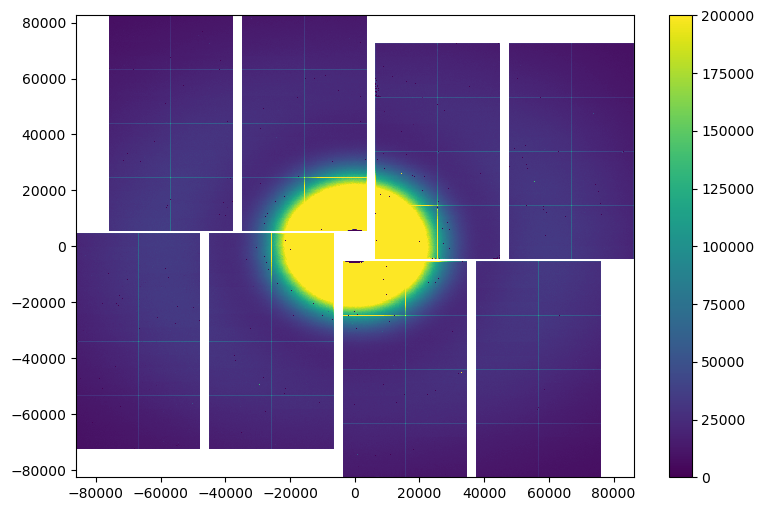

In [5]:
jungfrau_sum[jungfrau_sum>100*np.median(jungfrau_sum)]=0
r = np.sqrt(x**2+y**2)/1000
plt.figure(figsize=(9,6))
pcm = plot_jungfrau(-y,x,jungfrau_sum,vmax=2e5)
plt.colorbar(pcm)
plt.show()

# Mask out the bad pixels using cmask or mask created

/lscratch/davidjr/tmp/ipykernel_2050402/1014444375.py:37: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x[i],y[i],f[i],shading=shading,*args,**kwargs)


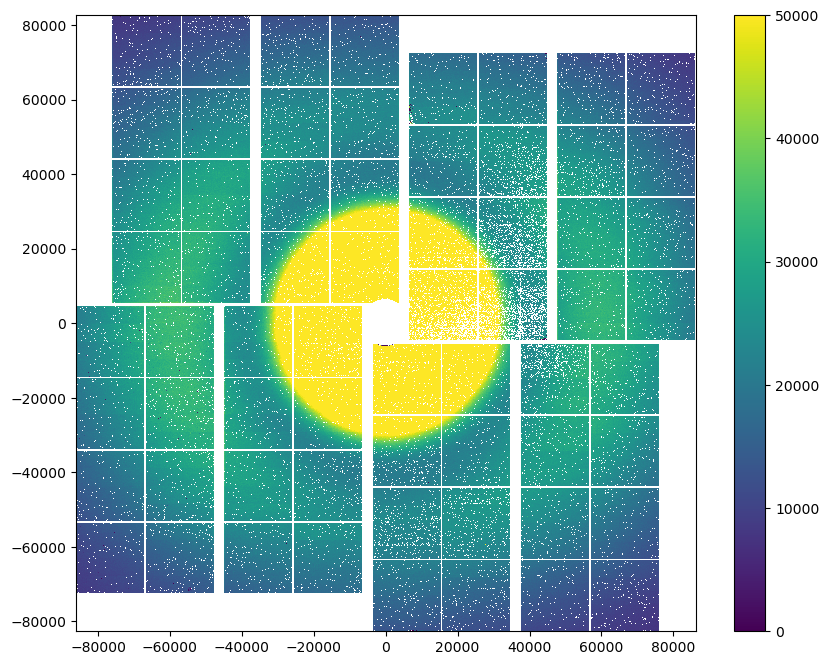

In [6]:
masked_jungfrau_sum = np.copy(jungfrau_sum)
masked_jungfrau_sum[~cmask] = np.nan
plt.figure(figsize=(10,8))
pcm = plot_jungfrau(-y,x,masked_jungfrau_sum,vmax=0.5*1e5)
plt.colorbar(pcm)
plt.show()

## Load 1-D scattering signal (elastic + inelastic) from sample molecule (usually SF6)

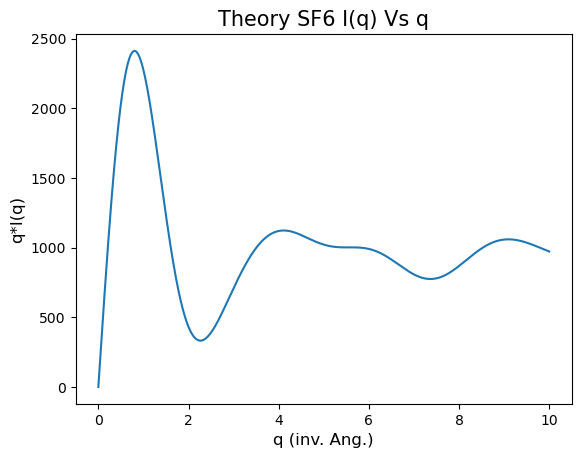

In [8]:
theory = np.loadtxt('./Theory/SF6_total.txt')
q_theory = theory[0]
I_theory = theory[1]
plt.figure()
plt.plot(q_theory,q_theory*I_theory)
plt.xlabel('q (inv. Ang.)',fontsize=12)
plt.ylabel('q*I(q)',fontsize=12)
plt.title('Theory SF6 I(q) Vs q',fontsize=15)
plt.show()

## Interpolate the theory scattering pattern to new values

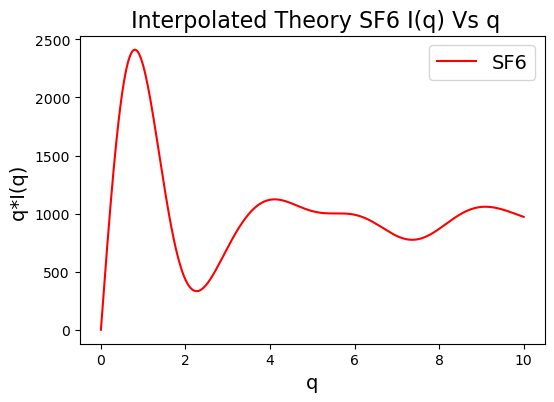

In [11]:
from scipy.interpolate import interp1d  # interpolate function loaded
import scipy.io
from scipy.interpolate import InterpolatedUnivariateSpline

# theoryN2 = scipy.io.loadmat('./Theory_Curves/N2_IAM_pattern.mat')
# # # print(theory.shape)
# q_theoryN2 = np.squeeze(theoryN2['q']) # theory[0,:]  (azav[onshots,:]*Intensity_Average/dg2_on).sum(axis=0)
# I_theoryN2 = np.squeeze(theoryN2['N2_IAM'])

I_pattern_theory = interp1d(q_theory,I_theory) # interpolated scattering pattern theory
# N2_theory_pattern = interp1d(q_theoryN2,I_theoryN2)

#det_test = np.load('detector_efficiency113keV_SiBeAl.npz')
#detq = det_test['qbin_det']
#det_efficiency = det_test['detector_efficiency']

from scipy.interpolate import InterpolatedUnivariateSpline

#et_Spline = InterpolatedUnivariateSpline(detq, det_efficiency)

# This function safely outputs a scattering pattern from interpolated values even if the q range is outside of the defined q.
def scattering_pattern_theory(q1,I_pattern_theory,q_theory):
    output = np.zeros_like(q1) # Allocating the output array
    output[q1>np.max(q_theory)] = I_pattern_theory(np.max(q_theory)) # Handling the edges with flat interpolation
    output[q1<np.min(q_theory)] = I_pattern_theory(np.min(q_theory))
    # Doing the actual interpolation for the range where I_pattern_theory is defined
    output[(q1<=np.max(q_theory))&(q1>=np.min(q_theory))] = I_pattern_theory(q1[(q1<=np.max(q_theory))&(q1>=np.min(q_theory))])
    return output


qs = np.linspace(np.min(q_theory),np.max(q_theory),1000)  # Defining new q range
#Splined_det = det_Spline(qs)


plt.figure(figsize=(6,4))
plt.plot(qs, qs*scattering_pattern_theory(qs,I_pattern_theory,q_theory),label='SF6',color='r')
# plt.plot(qs, qs*scattering_pattern_theory(qs,N2_theory_pattern,q_theoryN2),label='N2',color='b')
plt.xlabel('q',fontsize=14)
plt.ylabel('q*I(q) ',fontsize=14)
plt.title(' Interpolated Theory SF6 I(q) Vs q', fontsize=16)
plt.legend(fontsize=14)
plt.show()

# Define Fitting functions

In [12]:
def theta_to_q(theta):
    return 4*np.pi*np.sin(theta/2.)/(wavelength)

def q_to_theta(q):
    return 2*np.arcsin((wavelength*q)/(4*np.pi))

def xyz_to_q(x,y,xcenter,ycenter,z):
    xcent = x-xcenter
    ycent = y-ycenter
    r_xy = np.sqrt(xcent**2+ycent**2)
    theta = np.arctan(r_xy/z0)  # theta is scattering angle
    return theta_to_q(theta)

def get_thomson_correction(x,y,z,phi0=0):   
    r_xy = np.sqrt(x**2+y**2)
    theta = np.arctan(r_xy/z)
    phi = np.arctan2(y,x)+phi0
    #polarization correction due to polarized x-rays interaction with electrons
    correction = (np.sin(phi)**2+np.cos(theta)**2*np.cos(phi)**2)
    return correction

def get_geometry_correction(x,y,z):
    r_xy = np.sqrt(x**2+y**2)
    theta = np.arctan(r_xy/z)
    # correction due to intensity falling off as 1/R**2
    R2 =  (np.cos(theta))**2 #  = (x**2+y**2+z**2)/z**2 
    # correction due to flux through pixel area falling off with increased angle
    A = np.cos(theta)
    return R2*A

def xy_to_phi(x,y):
    return np.arctan2(y,x) # + np.pi


def fitting_function(xy,xcenter,ycenter,z0,amplitude):
    x = np.ravel(xy[0])
    y = np.ravel(xy[1])
    xcent = x-xcenter
    ycent = y-ycenter
    r_xy = np.sqrt(xcent**2+ycent**2)
    theta = np.arctan(r_xy/z0)
    Q_abs = theta_to_q(theta)
    # ff = amplitude*(a*scattering_pattern_theory(Q_abs,I_pattern_theory,q_theory) - (1-a)*scattering_pattern_theory(Q_abs,N2_theory_pattern,q_theoryN2))
    ff = amplitude*scattering_pattern_theory(Q_abs,I_pattern_theory,q_theory) 
    thomson_correction = get_thomson_correction(xcent,ycent,z0)
    geometry_correction = get_geometry_correction(xcent,ycent,z0)
    ff = ff*thomson_correction*geometry_correction  # divide the theory by correction factors to match the experiment data
    return ff

def fitting_function_freephi(xy,xcenter,ycenter,z0,amplitude,phi0):
    x = np.ravel(xy[0])
    y = np.ravel(xy[1])
    xcent = x-xcenter
    ycent = y-ycenter
    r_xy = np.sqrt(xcent**2+ycent**2)
    theta = np.arctan(r_xy/z0)
    Q_abs = theta_to_q(theta)
    ff = amplitude*scattering_pattern_theory(Q_abs,I_pattern_theory,q_theory)

    thomson_correction = get_thomson_correction(xcent,ycent,z0,phi0=phi0)
    geometry_correction = get_geometry_correction(xcent,ycent,z0)
    ff = ff*thomson_correction*geometry_correction
    return ff

# Fit pattern

In [13]:
from scipy.optimize import curve_fit

x0 = 0
y0 = 0
z0 = 95000
phi=0
# x0, y0 = 0,0
# z0 = 82000.

amplitude = 449.0357305848682

goodmask = np.ones_like(x).astype(bool)
goodmask[np.sqrt(x**2+y**2)<7500]=0  # all pixels below 7500 are et to 0

xgood = x[goodmask]
ygood = y[goodmask]
xy = [xgood,ygood]

params1 = np.array([x0,y0,z0,amplitude])

# curve fit to find bext values
params1, covariances1 = curve_fit(fitting_function,xy,np.ravel(jungfrau_sum[goodmask]),
                                p0=[x0,y0,z0,amplitude],
                                bounds=([-10000,-10000,30000,0],[10000,10000,150000,10000])) 

labels = ['x0','y0','z0','amp']

print('params1')
for i,label in enumerate(params1):
    print(labels[i],'=', float(params1[i])) # print values

params1
x0 = 350.8631197275235
y0 = -356.6688490965494
z0 = 91258.20039630926
amp = 190.9770831606129


## Show image of q*I(q) fitted theory to experiment 

/lscratch/davidjr/tmp/ipykernel_2050402/1014444375.py:37: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x[i],y[i],f[i],shading=shading,*args,**kwargs)


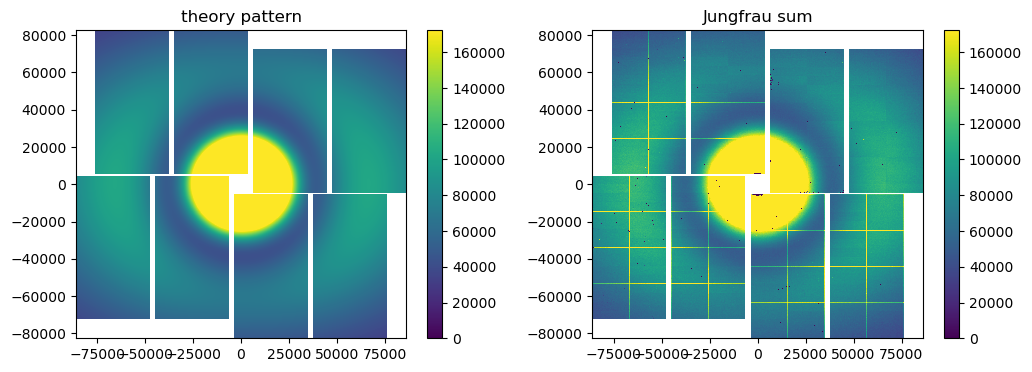

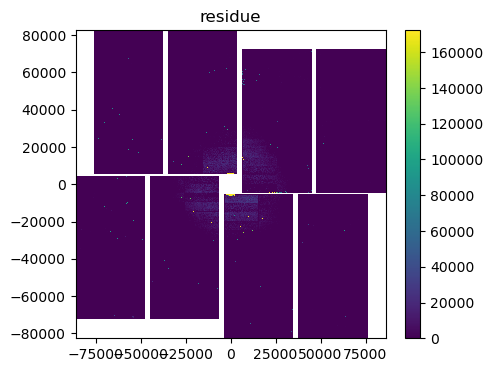

In [14]:
xy = [x,y]
x0 = params1[0]
y0 = params1[1]
z0 = params1[2]
amp = params1[3]
# phi = params1[4]
# manual additions
# x0 = 318.19686197368884
# y0 = -43.21838041984081
# z0 = 70092.61502970615

Q_new = xyz_to_q(x,y,x0,y0,z0)
# print(Q_new)
fitted_pattern = np.reshape(fitting_function(xy,*params1),(8,512,1024))  # Theory fit pattern to match the experiment

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
pcm = plot_jungfrau(-y,x,Q_new*fitted_pattern,vmin=0,vmax=np.max(fitted_pattern)/5)
plt.title('theory pattern')
plt.colorbar(pcm)
plt.subplot(1,2,2)
pcm = plot_jungfrau(-y,x,Q_new*jungfrau_sum,vmin=0,vmax=np.max(fitted_pattern)/5)
plt.title('Jungfrau sum')
plt.colorbar(pcm)
plt.subplots_adjust(hspace=0.25, wspace=0.25)
plt.show()

plt.figure(figsize=(5,4))
pcm = plot_jungfrau(-y,x,Q_new*(fitted_pattern-jungfrau_sum),vmin=0,vmax=np.max(fitted_pattern)/5)
plt.title('residue')
plt.colorbar(pcm)
plt.show()

In [18]:
# detector_info = np.load('xray_11keV_det_eff_correction_Kapton.npz')
q_det = np.load('detector_efficiency11keVq.npy')
y_detector = np.load('detector_efficiency11keVdet.npy')
detector_function = interp1d(q_det,y_detector) 

from scipy.interpolate import InterpolatedUnivariateSpline

det_Spline = InterpolatedUnivariateSpline(q_det, y_detector)

Splined_det = det_Spline(q_1d)



# 1D fitted theory and experiment data plot after corrections

In [15]:
import scipy.io

print('done')
theory_fit_1d = []
exp_1d = []

q_1d = np.linspace(np.min(Q_new),np.max(Q_new),100)
dq_1d = np.mean(np.diff(q_1d)) 


thomson_correction = get_thomson_correction(x-x0,y-y0,z0,0)

geometry_correction = get_geometry_correction(x-x0,y-y0,z0)
corrections = thomson_correction*geometry_correction
    
fitted_pattern_c = fitted_pattern/corrections # original theory pattern

# efficiency = detector_function(q_1d)
theoryN2 = scipy.io.loadmat('./Theory_Curves/N2_IAM_pattern.mat')
qN2 = np.squeeze(theoryN2['q'])
I_N2 = np.squeeze(theoryN2['N2_IAM'])

masked_jungfrau_sum = np.copy(jungfrau_sum)
masked_jungfrau_sum[~cmask] = np.nan
masked_jungfrau_sum = np.reshape(masked_jungfrau_sum,(8,512,1024))
masked_jungfrau_sum = masked_jungfrau_sum/corrections  #experiment corrected for Thomson & geometry corrections to match theory

for q1 in q_1d:
    theory_fit_1d.append(np.mean(fitted_pattern_c[(Q_new>q1)&(Q_new<q1+dq_1d)]))
    exp_1d.append(np.nanmean(masked_jungfrau_sum[(Q_new>q1)&(Q_new<q1+dq_1d)]))
    # resid_1d.append(np.mean(fitted_pattern_c[(Q_new>q1)&(Q_new<q1+dq_1d)]) - np.nanmean(masked_jungfrau_sum[(Q_new>q1)&(Q_new<q1+dq_1d)]))
    
plt.figure(figsize=(6,4))
# plt.plot(q_1d,q_1d*exp_1d*efficiency,'o',label='Experiment w efficiency corrections',linewidth=3)
plt.plot(q_1d,q_1d*exp_1d,'o',label='Experiment',linewidth=3)
plt.plot(q_1d,q_1d*theory_fit_1d,label='Theory',linewidth=3)
# plt.plot(q_1d,efficiency,label='residual',linewidth=3)
#plt.plot(qN2,qN2*I_N2)


plt.legend(fontsize=12)
plt.xlabel('q (inv. Ang)',fontsize=12)
plt.ylabel('q*I (arb)',fontsize=12)
plt.xlim(0,5)
# plt.ylim(-1e8, 1e5)
plt.title('Static SF6 at %.1f keV' % (photon_energy*1e-3),fontsize=15)
plt.show()

done


FileNotFoundError: [Errno 2] No such file or directory: './Theory_Curves/N2_IAM_pattern.mat'

In [53]:
print(exp_1d[:-1]/efficiency[:-1])
print(exp_1d[:-1])

[ 551998.30869468 1057902.54733065 1025429.98279973  973477.49400273
  919484.23874501  866245.83537317  808531.06284792  749880.62243562
  691599.35441836  631913.31576153  572578.94568798  517335.33956624
  464084.50185543  413077.5035114   365394.7147213   319593.40203477
  277268.05089445  238577.39067852  203839.14685844  172165.52372729
  145183.38750787  121973.31585497  102216.76512341   85450.01165438
   71720.48570722   60726.03902969   52060.81440913   45477.95967117
   40790.01081639   37765.94583275   36177.55380853   35673.46064581
   36014.70614774   36978.51743441   38563.9494193    40573.36881068
   42899.35783491   45301.51560124   47799.89078316   50247.36064937
   52604.43720495   54768.74026215   56919.20847012   58998.46560429
   60846.86737633   62266.07677462   63363.57900665   64355.12851509
   65178.23055196   65684.05847716   66033.47989485   66118.84818613
   66046.38151683   65843.29622515   65399.18557778   64629.40995543
   63813.5331816    62756.40487836

In [46]:
print(masked_jungfrau_sum.shape)

(8, 512, 1024)


In [49]:
# #First loading in the modules
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# plt.switch_backend('agg')
# import numpy as np
# import h5py
# from psana import *
# import tables
# from scipy.stats import norm
# from scipy.optimize import minimize
# from scipy.interpolate import InterpolatedUnivariateSpline

# #Next loading in and processing the experimental image and Instrument Response Function
# experiment = 'cxil1038423'
# instrument_response = np.ones((8,512,1024))
# #instrument_response = np.load('/cds/data/psdm/cxi/%s/results/Instrument_Response/IRF_Ne_run91_Jshaped_Calibrated.npy' % experiment)
# mask0 = np.load('Mask_Jungfrau_27_29.npy')
# molecule = 'SF6'
# # Combined_Image = np.load('LX65_Practice_Run96.npy')

# #Next Defining some parameters, and all the functions for the optimization
# x0 = np.array([269.3990507891946,-76.72737547503004,-76.72737547503004,0])
# # x0 = 269.3990507891946
# # y0 = -76.72737547503004
# # z0 = 94631.55755902534#np.array([338.943, 622.910, 89.877722,0.001])
# method = 'Nelder-Mead'
# bounds = ((-2000,2000),(-2000,2000),(60000,100000),(0.0000000000001,10000000000000))
# # X = np.load('X_Coordinates.npy')
# # Y = np.load('Y_Coordinates.npy')
# energy_keV = 11300. #eV
# wavelength = 12400./energy_keV #Angstrom
# wavelength *= 1e-10
# #wavelength = 0.077e-9


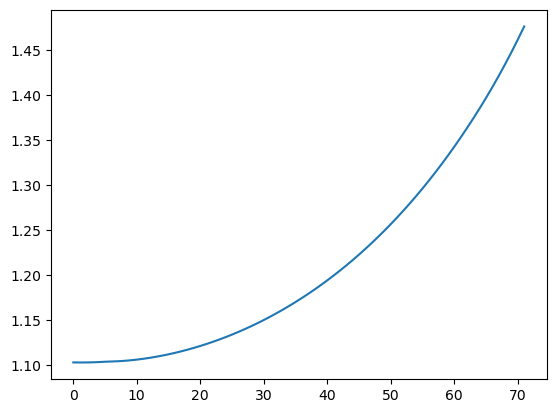

In [70]:
plt.plot(detector_function(qbins))

In [54]:

# def theta(x0, y0, z0):
#     return 0.5*np.arctan(np.sqrt((X+x0)**2 + (Y+y0)**2)/z0)

# def q(x0, y0, z0):
#     return 4 * np.pi * np.sin(theta(x0, y0, z0)) / wavelength * 1e-10

# def phi(x0, y0):
#     return np.arctan2((Y+y0),(X+x0)) + np.pi

# def polarization(x0, y0, z0):
#     return np.sin(phi(x0, y0))**2 + np.cos(phi(x0, y0))**2*np.cos(2*theta(x0,y0,z0))**2

# def experimental_image(x0, y0, z0):
#     return masked_jungfrau_sum/((np.cos(2*theta(x0, y0, z0))**3)*polarization(x0, y0, z0))

# theory_pattern = np.loadtxt('./Theory_Curves/SF6_total.txt')
# # mask = np.load('/sdf/data/lcls/ds/cxi/cxix1000021/results/Masks/Mask_Jungfrau_93_94.npy')
# q_theory = theory_pattern[0,:]
# scattering_theory = theory_pattern[1,:]

# q_square_scaled = scattering_theory*q_theory**2
# derivative_curve = np.zeros_like(scattering_theory)
# derivative_curve[0:scattering_theory.size-1] = abs((q_square_scaled[1:scattering_theory.size] - q_square_scaled[0:scattering_theory.size-1]))**(1./5.)
# derivative_curve[scattering_theory.size - 1] = derivative_curve[scattering_theory.size - 2]
# derivative_curve[0:50] = derivative_curve[50]
# derivative_curve /= 2
# weighting_curve = 1/derivative_curve




In [55]:
# ttheta = np.nan_to_num(np.arcsin((theory_pattern[0,:]*0.77)/(4*np.pi)))
# tI = np.nan_to_num(theory_pattern[1,:])
# tI = tI[np.nonzero(ttheta)]
# tweight = np.nan_to_num(weighting_curve)
# tweight = tweight[np.nonzero(ttheta)]
# ttheta = ttheta[np.nonzero(ttheta)]
# tspline = InterpolatedUnivariateSpline(ttheta,tI)
# weightspline = InterpolatedUnivariateSpline(ttheta, tweight)

# def theory_image(x0, y0, z0, I0):
#     return tspline(theta(x0, y0, z0))*mask*I0

# def weight_array(x0, y0, z0):
#     return weightspline(theta(x0, y0, z0))*mask
                              
# def error(x):
#     return abs((masked_jungfrau_sum(x[0],x[1],x[2]) - theory_image(x[0],x[1],x[2],x[3]))).sum()                     

# best_values = minimize(error, x0 = x0, method = method, bounds = bounds)

# print(best_values)

# if best_values.success == True:
#     np.savetxt('SF6_Best_Values.txt', best_values.x)

/lscratch/lhuang3/tmp/ipykernel_4085948/940807553.py:19: OptimizeWarning: Initial guess is not within the specified bounds
  best_values = minimize(error, x0 = x0, method = method, bounds = bounds)


TypeError: 'numpy.ndarray' object is not callable

AttributeError: 'function' object has no attribute 'shape'

In [26]:
# detector_info = np.load('detector_efficiency11keV.npy')
q_detector = np.load('detector_efficiency11keVq.npy')
detector_efficiency = np.load('detector_efficiency11keVdet.npy')

# # detector_efficiency = detector_info['qbins']
# # q_detector = detector_info[0,:]
# detector_function = interp1d(q_detector,detector_efficiency) 
# efficiency = detector_function(q_1d)
# print('done')
# plt.figure()
# plt.plot(q_1d,efficiency)
print(q_detector.shape )

(72,)


In [ ]:
plt.figure(figsize=(5,4))
pcm = plot_jungfrau(x,y,thomson_correction,vmin=0,vmax=1)
plt.title('thomson_correction')
plt.colorbar(pcm)
plt.show()

plt.figure(figsize=(5,4))
pcm = plot_jungfrau(x,y,geometry_correction,vmin=0,vmax=1)
plt.title('geometry_correction')
plt.colorbar(pcm)
plt.show()

In [45]:
# (np.load('./Calibrations/LX65_Practice_Run96.npy'))

ValueError: cannot reshape array of size 1703920 into shape (8,512,1024)